In [1]:
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NORMAL_BEATS = ['N']
ARRHYTHMIC_BEATS = ['S', 'V', 'Q']
VALID_BEATS = NORMAL_BEATS + ARRHYTHMIC_BEATS

data_folder = "icentia_data"

results = []

# loop through patients
for root, dirs, files in os.walk(data_folder):

    for file in files:

        if file.endswith(".atr"):  # annotation file

            record_name = file.replace(".atr", "")
            record_path = os.path.join(root, record_name)

            try:
                ann = wfdb.rdann(record_path, 'atr')
            except:
                print("Skipping:", record_name)
                continue

            # keep valid beats
            beat_mask = [s in VALID_BEATS for s in ann.symbol]
            beat_samples = ann.sample[beat_mask]
            beat_symbols = np.array(ann.symbol)[beat_mask]

            for i in range(1, len(beat_symbols)):

                prev_sym = beat_symbols[i-1]
                curr_sym = beat_symbols[i]

                interval = beat_samples[i] - beat_samples[i-1]

                if prev_sym in NORMAL_BEATS and curr_sym in NORMAL_BEATS:
                    transition = 'N→N'
                elif prev_sym in NORMAL_BEATS and curr_sym in ARRHYTHMIC_BEATS:
                    transition = 'N→A'
                elif prev_sym in ARRHYTHMIC_BEATS and curr_sym in ARRHYTHMIC_BEATS:
                    transition = 'A→A'
                else:
                    transition = 'A→N'

                results.append([record_name, transition, interval])


# ======================================================
# DATAFRAME
# ======================================================

df = pd.DataFrame(
    results,
    columns=['Record', 'Transition', 'BeatInterval_samples']
)

summary = (
    df.groupby('Transition')['BeatInterval_samples']
      .agg(['mean', 'std', 'min', 'median', 'count'])
      .reset_index()
)

print(summary)


/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Skipping: p00132_s46
Skipping: p00132_s47
Skipping: p00132_s45
Skipping: p00132_s49
Skipping: p00132_s48
  Transition        mean         std  min  median     count
0        A→A  187.698724  478.550229    0   174.0  24100883
1        A→N  229.781465  550.126894   27   219.0   1783332
2        N→A  157.033522  413.878199   16   148.0   1783550
3        N→N  208.157059   63.657746   23   204.0  73436110


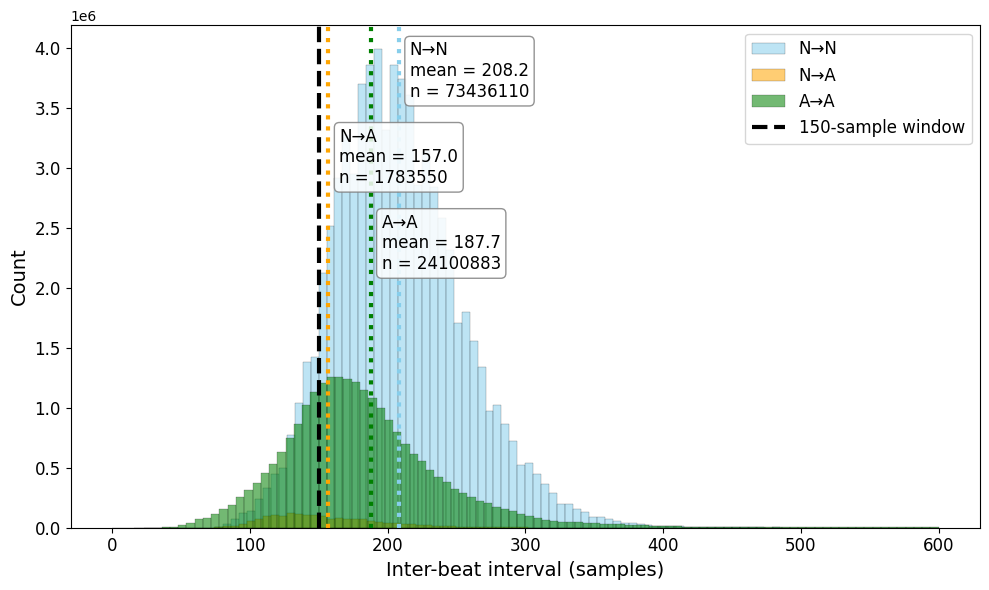

In [2]:
# ======================================================
# PLOT
# ======================================================

stats = summary.set_index('Transition')

MAX_INTERVAL = 600
df_clipped = df[df['BeatInterval_samples'] <= MAX_INTERVAL]

plt.figure(figsize=(10,6))

ymax = 0

# Original colors (kept same as your first plot)
color_map = {
    'N→N': 'skyblue',
    'N→A': 'orange',
    'A→A': 'green'
}

# vertical spacing for labels
text_height = {
    'N→N': 0.90,
    'N→A': 0.72,
    'A→A': 0.54
}

for transition in ['N→N', 'N→A', 'A→A']:

    data = df_clipped[df_clipped['Transition']==transition]['BeatInterval_samples']

    counts, bins, _ = plt.hist(
        data,
        bins=100,
        alpha=0.55,                 # slightly stronger color
        label=transition,
        color=color_map[transition],
        edgecolor='black',
        linewidth=0.25
    )

    ymax = max(ymax, counts.max())

# window line
plt.axvline(150, linestyle='--', linewidth=3, color='black', label='150-sample window')

# mean lines + annotations
for transition in ['N→N', 'N→A', 'A→A']:

    mean_val = stats.loc[transition, 'mean']
    count_val = int(stats.loc[transition, 'count'])

    plt.axvline(
        mean_val,
        linestyle=':',
        linewidth=3,
        color=color_map[transition]
    )

    plt.text(
        mean_val + 8,
        ymax * text_height[transition],
        f'{transition}\nmean = {mean_val:.1f}\nn = {count_val}',
        fontsize=12,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round,pad=0.3'
        )
    )

plt.xlabel('Inter-beat interval (samples)', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig('icentia_interbeat_distribution.png', dpi=300)

plt.show()